In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import exp

# Dataset

## Deep Learning SIAM Paper

Here, the model is a 3-layer neural network with 2, 3, and 2 nodes respectively. The training uses the stochastic gradient method and has the following given data:

$$\text{Inputs} = \left\{\begin{bmatrix}0.1 \\ 0.1\end{bmatrix}, \begin{bmatrix}0.3 \\ 0.4\end{bmatrix}, \begin{bmatrix}0.1 \\ 0.5\end{bmatrix}, \begin{bmatrix}0.6 \\ 0.9\end{bmatrix}, \begin{bmatrix}0.4 \\ 0.2\end{bmatrix}, \begin{bmatrix}0.6 \\ 0.3\end{bmatrix}, \begin{bmatrix}0.5 \\ 0.6\end{bmatrix}, \begin{bmatrix}0.9 \\ 0.2\end{bmatrix}, \begin{bmatrix}0.4 \\ 0.4\end{bmatrix}, \begin{bmatrix}0.7 \\ 0.6\end{bmatrix}\right\}$$

$$\text{Outputs} = \left\{\begin{bmatrix}1 \\ 0\end{bmatrix}, \begin{bmatrix}1 \\ 0\end{bmatrix}, \begin{bmatrix}1 \\ 0\end{bmatrix}, \begin{bmatrix}1 \\ 0\end{bmatrix}, \begin{bmatrix}1 \\ 0\end{bmatrix}, \begin{bmatrix}0 \\ 1\end{bmatrix}, \begin{bmatrix}0 \\ 1\end{bmatrix}, \begin{bmatrix}0 \\ 1\end{bmatrix}, \begin{bmatrix}0 \\ 1\end{bmatrix}, \begin{bmatrix}0 \\ 1\end{bmatrix}\right\}$$

In [2]:
# Data

X = torch.tensor([[0.1 ,0.3,0.1,0.6, 0.4,0.6,0.5,0.9,0.4,0.7],[0.1,0.4,0.5,0.9,0.2,0.3,0.6,0.2,0.4,0.6]],dtype=torch.float64)
Y = torch.tensor([[1,1,1,1,1,0,0,0,0,0],[0,0,0,0,0,1,1,1,1,1]],dtype=torch.float64)

In [3]:
X.shape

torch.Size([2, 10])

# Model

The neural network model can be described as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[1]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=1:L-1
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a datapoint, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the matrix of weights that layer $l+1$ applies to the output of layer $l$ and $L$ is the total number of layers.

For any $l=2:L$, $\boldsymbol{\sigma}:\mathbb{R}^{n_l}\rightarrow\mathbb{R}^{n_l}$ is the non-linear activation function applied component-wise as follows:
$$
\begin{align*}
    \boldsymbol{\sigma}(\boldsymbol{x}) = (\sigma_1(\boldsymbol{x}),\cdots,\sigma_{n_l}(\boldsymbol{x}))^T = (\tilde{\sigma}(x_1),\cdots,\tilde{\sigma}(x_{n_l}))^T
\end{align*}
$$

where $\tilde{\sigma}:\mathbb{R}\rightarrow\mathbb{R}$ is the tanh or sigmoid activation function.

$\textbf{State space:}$ $N$ datapoints each with dimension $n_1$ and $\boldsymbol{a}^{[l]}\in\mathbb{R}^{n_l}$ for $l=2:L$

$\textbf{Parameter space:}$ $W^{[l]}\in\mathbb{R}^{n_l\times n_{l-1}}$, $\boldsymbol{b}^{[l]}\in\mathbb{R}^{n_l}$ for $l=2:L$

Number of weights = $\sum_{l=1}^{L-1}n_ln_{l+1}$

Number of biases = $\sum_{l=1}^{L-1}n_{l+1}$

Total number of parameters = $\sum_{l=1}^{L-1} (n_l+1)n_{l+1} = \sum_{l=1}^{L-1} m_{l+1}$, 

where $m_{l+1} = (n_l+1)n_{l+1}$ is the number of parameters at layer $l+1$.

For any $l=1:L-1$

$$
\begin{align*}
    &\boldsymbol{z}^{[l+1]} = W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\\
    \implies &\boldsymbol{a}^{[l+1]} = \boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})
\end{align*}
$$

and

$$
\begin{align*}
    W^{[l+1]} = 
    \begin{pmatrix}
        | & & |\\
        \boldsymbol{w}_1^{[l+1]} & \dots & \boldsymbol{w}_{n_l}^{[l+1]}\\
        | & & |
    \end{pmatrix}
\end{align*}
$$
where $\boldsymbol{w}_j^{[l+1]}$ is the $j$-th column of $W^{[l+1]}$.

Then, we get

$$
\begin{align*}
    \boldsymbol{z}^{[l+1]} = a_1^{[l]}\boldsymbol{w}_1^{[l+1]}+\dots+a_{n_l}^{[l]}\boldsymbol{w}_{n_l}^{[l+1]} + \boldsymbol{b}^{[l+1]}
\end{align*}
$$

For any $l=1:L-1$, define the parameter vector $\boldsymbol{u}^{[l+1]}\in\mathbb{R}^{m_{l+1}}$ as

$$
    \boldsymbol{u}^{[l+1]} = (\boldsymbol{b}^{[l+1]},\boldsymbol{w}_1^{[l+1]},\dots,\boldsymbol{w}_{n_l}^{[l+1]})^T
$$

## Implementing the model

To simplify the implementation, we consider $L = 4$.

In [4]:
# activation function and derivative

def tanh(x):

    return (exp(x) - exp(-x))/(exp(x)+exp(-x))

def tanh_prime(x):

    return 1 - tanh(x)**2

def sigmoid(x):

    return 1/(1+exp(-x))

def sigmoid_prime(x):

    return sigmoid(x)*(1-sigmoid(x))

In [5]:
# initialize parameters
L = 4
n = {1:X.shape[0]}
n[2], n[3], n[4] = 2,3,2

In [6]:
def generate_random_weights_and_baises(n,L):
    W = {}
    b = {}

    for l in range(2,L+1):
        W[l] = torch.randn(n[l], n[l-1], dtype=torch.float64)
        b[l] = torch.randn(n[l],1, dtype= torch.float64)

    return W,b

W,b = generate_random_weights_and_baises(n,L)

In [7]:
def NN_model(x, W, b, activation, L=4):
    # x is shape (D, N) - each column is a datapoint
    a = {1: x}
    z = {}  
    
    for l in range(2, L + 1):
        z[l] = W[l] @ a[l-1] + b[l]
        
        if l == L:
            a[l] = sigmoid(z[l])        # final layer
        else:
            a[l] = activation(z[l])
            
    return a,z

In [8]:
a,z = NN_model(X,W, b, tanh)

In [9]:
n_parameters = torch.sum(torch.tensor([n[l]*n[l+1] for l in range(1,L)])) + torch.sum(torch.tensor([n[l] for l in range(2,L+1)]))
print(f"Total number of parameters: {n_parameters}")

Total number of parameters: 23


# Loss function

The loss function for $i$-th datapoint is the binary cross-entropy loss

$$
\begin{align*}
    % C(y^{(i)},\hat{y}^{(i)}) = -\left[y^{(i)}\log(\hat{y}^{(i)})+(1-y^{(i)})\log(1-\hat{y}^{(i)})\right]
     C(y^{(i)},\hat{y}^{(i)}) = \frac{1}{2}\left[||y^{(i)} - \hat{y}^{(i)}||^2_2\right]
\end{align*}
$$

The loss function for the entire dataset can be given as
$$
\begin{align*}
    J(y,\hat{y}) &= \frac{1}{N}\sum_{i=1}^{N} C(y^{(i)},\hat{y}^{(i)})\\
    &=\frac{1}{N}\sum_{i=1}^{N}\frac{1}{2}\left[||y^{(i)} - \hat{y}^{(i)}||^2_2\right]
\end{align*}
$$

For all $i=1:N$, $\hat{y}^{(i)}=a^{[L](i)} $ are the predicted probabilities and $y^{(i)}$ denote the actual labels.

## Implementing the loss function

In [10]:
def C(y_hat,y):
    return 1/2*torch.sum((y-y_hat)**2)

def J(Y_hat,Y):
    N = Y.shape[1]
    return 1/N*torch.sum(torch.tensor([C(Y_hat[:,i],Y[:,i]) for i in range(N)]))

In [11]:
Y_hat = a[4].squeeze()
loss= J(Y_hat,Y)
loss

tensor(0.3729, dtype=torch.float64)

# FOA

Derivative of the activation function $\boldsymbol{\sigma}:\mathbb{R}^{n_l}\rightarrow\mathbb{R}^{n_l}$ is given by 

$$
\begin{align*}
    \nabla_{\boldsymbol{z}} \boldsymbol{\sigma}(\boldsymbol{z}) = \text{diag}(\tilde{\sigma}'(z_1),\dots,\tilde{\sigma}'(z_{n_l}))\in\mathbb{R^{n_l\times n_l}}
\end{align*}
$$

First order variation in $J$ is given by

$$
\begin{align*}
    \delta J &=  \frac{1}{N}\sum_{i=1}^N \delta C \\
    &= \frac{1}{N}\sum_{i=1}^N \left(a^{[L](i)}-y^{(i)}\right)\delta a^{[L](i)}
\end{align*}
$$

The tangent linear model is given by

$$
\begin{align*}
    \boldsymbol{\delta a}^{[1]} &= \boldsymbol{0}\\
    \boldsymbol{\delta a}^{[l+1]} &=\frac{\partial}{\partial \boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\delta a}^{[l+1]} +\frac{\partial}{\partial \boldsymbol{b}^{[l+1]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\delta b}^{[l+1]} + \sum_{j=1}^{n_l}\frac{\partial}{\partial \boldsymbol{w}_j^{[l+1]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\delta w}_j^{[l+1]}  \,,\quad \quad l=1:L-1
\end{align*}
$$

Taking innter product with $\boldsymbol{\lambda}^{[l+1]}\in \mathbb{R}^{n_{l+1}}$, we get

$$
\begin{align*}
    \langle \boldsymbol{\delta a}^{[l+1]}, \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} &= 
    \langle \boldsymbol{\delta a}^{[l]}, \nabla_{\boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\lambda}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} 
    + \langle \boldsymbol{\delta b}^{[l+1]},\nabla_{\boldsymbol{b}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} 
    + \sum_{j=1}^{n_l} \langle \boldsymbol{\delta w}_j^{[l+1]}, \nabla_{\boldsymbol{w}_j^{[l+1]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}}\\
    &= \langle\boldsymbol{\delta a}^{[l]}, \nabla_{\boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\lambda}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} 
    + \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Define

$$
\begin{align*}
        \boxed{
        \begin{split}
        \lambda^{[L](i)} &= a^{[L](i)}-y^{(i)}\\
        \boldsymbol{\lambda}^{[l](i)} &=\nabla_{\boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{\lambda}^{[l+1](i)}\,,\quad \quad l=1:L-1
        \end{split}
        }
\end{align*}
$$

Then, we get

$$
\begin{align*}
    \langle \boldsymbol{\delta a}^{[l+1]}, \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} - \langle \boldsymbol{\delta a}^{[l]}, \boldsymbol{\lambda}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} = \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Summing from $l=1:L-1$, we get

$$
\begin{align*}
    \sum_{l=1}^{L-1} \left(\langle \boldsymbol{\delta a}^{[l+1]}, \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} - \langle \boldsymbol{\delta a}^{[l]}, \boldsymbol{\lambda}^{[l]} \rangle_{\mathbb{R}^{n_{l}}}\right) &= \sum_{l=1}^{L-1} \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}\\
    \implies \langle \boldsymbol{\delta a}^{[L]}, \boldsymbol{\lambda}^{[L]} \rangle_{\mathbb{R}^{n_{L}}} - \langle \boldsymbol{\delta a}^{[1]}, \boldsymbol{\lambda}^{[1]} \rangle_{\mathbb{R}^{n_{1}}} &= \sum_{l=1}^{L-1} \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\lambda}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}\\
    \implies \left(a^{[L](i)}-y^{(i)}\right) \delta a^{[L](i)} &= \sum_{l=1}^{L-1} \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)} \rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Now, summing from $i=1:N$, we get

$$
\begin{align*}
    \frac{1}{N} \sum_{i=1}^N \left(a^{[L](i)}-y^{(i)}\right) \delta a^{[L](i)} &= \frac{1}{N} \sum_{i=1}^N \sum_{l=1}^{L-1} \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)} \rangle_{\mathbb{R}^{m_{l+1}}}\\
    \implies \delta \tilde{J} &= \frac{1}{N} \sum_{i=1}^N \sum_{l=1}^{L-1} \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)} \rangle_{\mathbb{R}^{m_{l+1}}} \\
    &= \sum_{l=1}^{L-1} \langle \boldsymbol{\delta u}^{[l+1]},\frac{1}{N} \sum_{i=1}^N \nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)} \rangle_{\mathbb{R}^{m_{l+1}}}\\
\end{align*}
$$

Then,
$$
    \boxed{\nabla_{\boldsymbol{u}^{[l+1]}} \tilde{J} = \frac{1}{N} \sum_{i=1}^N \nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)}\quad\text{ for }l=1:L-1}
$$

For any $j=1:n_l$, 

$$
\begin{align*}
    \nabla_{\boldsymbol{w}_j^{[l+1]}} \tilde{J} &= \frac{1}{N} \sum_{i=1}^N \nabla_{\boldsymbol{w}_j^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)}
\end{align*}
$$

where

$$
\begin{align*}
    \nabla_{\boldsymbol{w}_j^{[l+1]}}\boldsymbol{a}^{[l+1]} &= \nabla_{\boldsymbol{w}_j^{[l+1]}}\boldsymbol{z}^{[l+1]}\nabla_{\boldsymbol{z}^{[l+1]}}\boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})\\
    &= \nabla_{\boldsymbol{w}_j^{[l+1]}}(\boldsymbol{b}^{[l+1]}+a_1^{[l]}\boldsymbol{w}_1^{[l+1]}+\dots+a_{n_l}^{[l]}\boldsymbol{w}_{n_l}^{[l+1]})\text{diag}(\tilde{\sigma}'(z_1^{[l+1]}),\dots,\tilde{\sigma}'(z_{n_{l+1}}^{[l+1]}))\\
    &= a_j^{[l]}\text{diag}(\tilde{\sigma}'(z_1^{[l+1]}),\dots,\tilde{\sigma}'(z_{n_{l+1}}^{[l+1]}))
\end{align*}
$$

Also,
$$
\begin{align*}
    \nabla_{\boldsymbol{b}^{[l+1]}} \tilde{J} &= \frac{1}{N} \sum_{i=1}^N \nabla_{\boldsymbol{b}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\lambda}^{[l+1](i)}
\end{align*}
$$
where 
$$
\begin{align*}
    \nabla_{\boldsymbol{b}^{[l+1]}}\boldsymbol{a}^{[l+1]} &= \nabla_{\boldsymbol{b}^{[l+1]}}\boldsymbol{z}^{[l+1](i)}\nabla_{\boldsymbol{z}^{[l+1]}}\boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})\\
    &=\nabla_{\boldsymbol{b}^{[l+1]}}(\boldsymbol{b}^{[l+1]}+a_1^{[l]}\boldsymbol{w}_1^{[l+1]}+\dots+a_{n_l}^{[l]}\boldsymbol{w}_{n_l}^{[l+1]}) \text{diag}(\tilde{\sigma}'(z_1^{[l+1]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l+1]}))\\
    &= \text{diag}(\tilde{\sigma}'(z_1^{[l+1]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l+1]}))
\end{align*}
$$

Furthermore,

$$
\begin{align*}
    \nabla_{\boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]} &=\nabla_{\boldsymbol{a}^{[l]}}\boldsymbol{z}^{[l+1](i)} \nabla_{\boldsymbol{z}^{[l+1]}}\boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})\\
    &= \nabla_{\boldsymbol{a}^{[l]}}(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]})\text{diag}(\tilde{\sigma}'(z_1^{[l+1]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l+1]}))\\
    &= \left(W^{[l+1]}\right)^T\text{diag}(\tilde{\sigma}'(z_1^{[l+1]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l+1]}))
\end{align*}
$$

## Implementing FOA

In [12]:
# computing d/dz of sigma(z)
def compute_d_sigma_z(a,z,d_activation,L=4):
    d_sigma_z = {}
    for l in range(2, L + 1):
        if l == L:
            d_sigma_z[l] = sigmoid_prime(a[l])
        else:
            d_sigma_z[l] = d_activation(z[l])
    return d_sigma_z

In [13]:
# first-order adjoint
def foa(a, z, y, W, d_sigma_z, L=4):
    lambdas = {}
    
    # # d/dz sigma(z)
    # d_sigma_z = compute_d_sigma_z(a,z,d_activation, L)

    # Adjoint Equations (Backward Propogation)
    # lambdas[L] = -(y / a[L] - (1 - y) / (1 - a[L])) 
    lambdas[L] = a[L] - y
    for l in range(L - 1, 1, -1):
        # Element-wise multiplication for the diagonal Jacobian effect
        delta = d_sigma_z[l+1] * lambdas[l+1] 
        
        lambdas[l] = W[l+1].T @ delta
    return lambdas

In [14]:
def compute_gradients(lambdas,y,a,z,d_sigma_z,L=4):
    N = y.shape[1] 
    gradJ = {'W': {}, 'b': {}}

    # # d/dz sigma(z)
    # d_sigma_z = compute_d_sigma_z(a,z,d_activation, L)

    # Gradient Computation
    for l in range(L, 1, -1):
        delta = d_sigma_z[l] * lambdas[l]  
        
        gradJ['W'][l] =(delta @ a[l-1].T) / N

        gradJ['b'][l] = torch.sum(delta, dim=1, keepdim=True) / N
        
    return gradJ

In [15]:
def gradient_descent_iteration(W, b, gradJ, learning_rate, L=4):
    with torch.no_grad():
        for l in range(2, L + 1):
            W[l] -= learning_rate * gradJ['W'][l]
            b[l] -= learning_rate * gradJ['b'][l]
    return W, b

In [16]:
def train_network(X, y, W, b, epochs, learning_rate, L=4, verbose=False):
    N = X.shape[1]
    loss_history = []
    
    for epoch in range(epochs):
        # k = torch.randint(N,(1,))

        # Forward Pass
        a, z = NN_model(X, W, b, sigmoid, L)
        
        # compute Loss 
        loss = J(a[L].squeeze(), y)
        loss_history.append(loss.item())

        # compute d/dz sigma(z)
        d_sigma_z = compute_d_sigma_z(a,z,sigmoid_prime, L)

        # backward pass    
        lambdas = foa(a, z, y, W,d_sigma_z, L)
        gradJ = compute_gradients(lambdas, y,a,z,d_sigma_z,L)
        
        # Gradient Descent Step
        W, b = gradient_descent_iteration(W, b, gradJ, learning_rate, L=L)
        
        if epoch % 1e5 == 0 and verbose == True:
            print(f"Epoch {epoch} | Loss: {loss.item()}")
            
    return W, b, loss_history, gradJ

In [17]:
W,b, loss_history, gradJ = train_network(X,Y,W,b,int(1e6),0.05,4,True)

Epoch 0 | Loss: 0.33227873923408285
Epoch 100000 | Loss: 0.00012941861010781246
Epoch 200000 | Loss: 1.0902734603758738e-05
Epoch 300000 | Loss: 3.3826795116387113e-06
Epoch 400000 | Loss: 1.570973877438392e-06
Epoch 500000 | Loss: 8.886361700309589e-07
Epoch 600000 | Loss: 5.650017413484295e-07
Epoch 700000 | Loss: 3.881059244186338e-07
Epoch 800000 | Loss: 2.816364680081985e-07
Epoch 900000 | Loss: 2.1292235186062863e-07


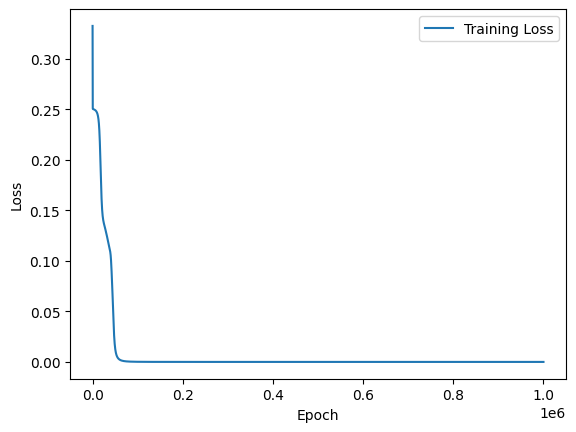

In [18]:
epochs = np.arange(int(1e6))

plt.plot(epochs, np.array(loss_history), label = "Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
gradJ

{'W': {4: tensor([[ 1.6885e-05,  5.1878e-06, -1.8041e-05],
          [-1.6766e-05, -5.1643e-06,  1.7818e-05]], dtype=torch.float64),
  3: tensor([[-1.0624e-05, -9.6851e-06],
          [-3.0374e-06, -4.4890e-06],
          [ 9.9847e-06,  1.0698e-05]], dtype=torch.float64),
  2: tensor([[-9.8054e-06,  7.9572e-06],
          [-1.8763e-05, -1.2150e-05]], dtype=torch.float64)},
 'b': {4: tensor([[-8.6641e-07],
          [ 7.6828e-07]], dtype=torch.float64),
  3: tensor([[ 1.4254e-05],
          [ 6.0391e-06],
          [-1.4410e-05]], dtype=torch.float64),
  2: tensor([[-2.1220e-07],
          [ 1.1681e-05]], dtype=torch.float64)}}

# SOA

## TLM Derivation

Consider the quantity $\tilde{q}$ defined by

$$
\begin{align*}
    \tilde{q}(\boldsymbol{u}) &= \sum_{l=2}^L \langle \nabla_{\boldsymbol{u}^{[l]}} \tilde{J},\boldsymbol{v}^{[l]}\rangle_{R^{m_l}}\\
    &= \sum_{l=2}^L \frac{1}{N}\sum_{i=1}^N\langle \nabla_{\boldsymbol{u}^{[l]}} \boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]},\boldsymbol{v}^{[l]}\rangle_{R^{m_l}}
\end{align*}
$$

The first order variation in $q$ is given by

$$
\begin{align*}
    \delta \tilde{q} = \frac{1}{N}\sum_{l=2}^L\sum_{i=1}^N \left[\langle \left(\nabla_{\boldsymbol{u}^[l]}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}}\boldsymbol{\delta a}^{[l-1]},\boldsymbol{v}^{[l]}\rangle_{\mathbb{R}^{m_l}}
    + \langle \left(\nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{u}^{[l]}}\boldsymbol{\delta u}^{[l]},\boldsymbol{v}^{[l]}\rangle_{\mathbb{R}^{m_l}}
    
    + \langle \nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\delta \lambda}^{[l]},\boldsymbol{v}^{[l]}\rangle_{\mathbb{R}^{m_l}}
    \right]
\end{align*}
$$

For $l=2:L$, define

$A^{[l]} = \left(\nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}}\quad\in \mathbb{R}^{m_l\times n_{l-1}}$

and, $B^{[l]} = \left(\nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{u}^{[l]}}\quad\in \mathbb{R}^{m_l\times m_{l}}$ .

Then, 

$$
\begin{align*}
    \delta \tilde{q} = \frac{1}{N}\sum_{i=1}^N \left[\sum_{l=2}^L\langle \boldsymbol{\delta a}^{[l-1]},\left(A^{[l]}\right)^T\boldsymbol{v}^{[l]}\rangle_{\mathbb{R}^{n_{l-1}}}
        + \sum_{l=2}^L\langle \boldsymbol{\delta u}^{[l]},\left(B^{[l]}\right)^T\boldsymbol{v}^{[l]}\rangle_{\mathbb{R}^{m_l}}
        + \sum_{l=2}^L\langle \boldsymbol{\delta \lambda}^{[l]},\left(\nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\right)^T\boldsymbol{v}^{[l]}\rangle_{\mathbb{R}^{n_l}}
        \right]
\end{align*}
$$

We want to eliminate $\boldsymbol{\delta a}^{[l-1]}$ and $\boldsymbol{\delta \lambda}^{[l]}$ from thr above equation. From FOA, we get

$$
\begin{align*}
    \delta \lambda^{[L](i)} &= \delta a^{[L](i)}\\
    \boldsymbol{\delta \lambda}^{[l](i)} &= \left(\nabla_{\boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{\lambda}^{[l+1](i)}\right)_{\boldsymbol{a}^{[l](i)}} \boldsymbol{\delta a}^{[l](i)} + \left(\nabla_{\boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{\lambda}^{[l+1](i)}\right)_{\boldsymbol{u}^{[l+1]}} \boldsymbol{\delta u}^{[l+1]} + \nabla_{\boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\delta \lambda}^{[l+1](i)}
\end{align*}
$$

For $l=1:L-1$,  define 

$C^{[l+1](i)} = \left(\nabla_{\boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{\lambda}^{[l+1](i)}\right)_{\boldsymbol{a}^{[l](i)}}\quad\in \mathbb{R}^{n_l\times n_{l}}$

and, $D^{[l+1](i)} = \left(\nabla_{\boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{\lambda}^{[l+1](i)}\right)_{\boldsymbol{u}^{[l+1]}}\quad\in \mathbb{R}^{n_l\times m_{l+1}}$ .

Now, taking inner product with $\boldsymbol{\xi}^{[l](i)}\in\mathbb{R}^{n_l}$ , we get

$$
\begin{align*}
    \langle \boldsymbol{\delta \lambda}^{[l]},\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}}&=  \langle \boldsymbol{\delta a}^{[l]}, \left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}} + \langle \boldsymbol{\delta u}^{[l+1]}, \left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}}+ \langle \boldsymbol{\delta \lambda}^{[l+1]}, \frac{\partial}{\partial \boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_{l+1}}}\\

    \implies \langle \boldsymbol{\delta \lambda}^{[l]},\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}} &- \langle \boldsymbol{\delta \lambda}^{[l+1]}, \frac{\partial}{\partial \boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_{l+1}}} = \langle \boldsymbol{\delta a}^{[l]}, \left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}} + \langle \boldsymbol{\delta u}^{[l+1]}, \left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Define 

$$
\begin{align*}
        \boxed{
        \begin{split}
        \boldsymbol{\xi}^{[1](i)} &= \boldsymbol{0}\\
        \boldsymbol{\xi}^{[l+1](i)} &=\frac{\partial}{\partial \boldsymbol{a}^{[l](i)}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{\xi}^{[l](i)} + \frac{\partial}{\partial \boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{v}^{[l+1]}\,,\quad \quad l=1:L-1
        \end{split}
        }
\end{align*}
$$

$$
\begin{align*}
    \langle \boldsymbol{\delta \lambda}^{[l]},\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}} &- \langle \boldsymbol{\delta \lambda}^{[l+1]}, \boldsymbol{\xi}^{[l+1]}\rangle_{\mathbb{R}^{n_{l+1}}} + \langle \boldsymbol{\delta \lambda}^{[l+1]}, \frac{\partial}{\partial \boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)}\boldsymbol{v}^{[l+1]}\rangle_{\mathbb{R}^{n_{l+1}}} \\
    =&\langle \boldsymbol{\delta a}^{[l]}, \left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}} + \langle \boldsymbol{\delta u}^{[l+1]}, \left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Summing from $l=1:L-1$,

$$
\begin{align*}
    \langle \boldsymbol{\delta \lambda}^{[1]},\boldsymbol{\xi}^{[1]}\rangle_{\mathbb{R}^{n_1}} &- \langle \delta \lambda^{[L]}, \xi^{[L]}\rangle_{\mathbb{R}^{n_{L}}} + \underbrace{\sum_{l=1}^{L-1}\langle \boldsymbol{\delta \lambda}^{[l+1]}, \left(\nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\right)^T\boldsymbol{v}^{[l+1]}\rangle_{\mathbb{R}^{n_{l+1}}}}_{} \\
    &= \sum_{l=1}^{L-1}\langle \boldsymbol{\delta a}^{[l]}, \left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}} + \sum_{l=1}^{L-1}\langle \boldsymbol{\delta u}^{[l+1]}, \left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Then,
$$
\begin{align*}
        \delta \tilde{q} = -\frac{1}{N}\sum_{i=1}^N [
                
        &\sum_{l=1}^{L-1}\langle \boldsymbol{\delta a}^{[l]},\left(A^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}}
        + \sum_{l=1}^{L-1}\langle \boldsymbol{\delta u}^{[l+1]},\left(B^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}} \\

        &+ \langle \delta \lambda^{[L]}, \xi^{[L]}\rangle_{\mathbb{R}^{n_{L}}}
        ]\\


        = -\frac{1}{N}\sum_{i=1}^N [
        &\sum_{l=1}^{L-1}\langle \boldsymbol{\delta a}^{[l]},\left(A^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{n_l}}
        + \sum_{l=1}^{L-1}\langle \boldsymbol{\delta u}^{[l+1]},\left(B^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}} \\

        & + \langle \delta a^{[L]}, \xi^{[L]}\rangle_{\mathbb{R}^{n_{L}}}
        ]
\end{align*}
$$

## SOA Derivation

Now,
$$
\begin{align*}
    \boldsymbol{\delta a}^{[1]} &= \boldsymbol{0}\\
    \boldsymbol{\delta a}^{[l+1]} &=\frac{\partial}{\partial \boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\delta a}^{[l+1]} +\frac{\partial}{\partial \boldsymbol{b}^{[l+1]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\delta b}^{[l+1]} + \sum_{j=1}^{n_l}\frac{\partial}{\partial \boldsymbol{w}_j^{[l+1]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\delta w}_j^{[l+1]}  \,,\quad \quad l=1:L-1
\end{align*}
$$

Taking inner product with $\boldsymbol{\eta}^{[l+1]}\in \mathbb{R}^{n_{l+1}}$, we get

$$
\begin{align*}
    \langle \boldsymbol{\delta a}^{[l+1]}, \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} &= \langle\boldsymbol{\delta a}^{[l]}, \nabla_{\boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{n_{l}}} 
    + \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Define

$$
\begin{align*}
        \boxed{
        \begin{split}
        \eta^{[L](i)} &= \xi^{[L](i)}\\
        \boldsymbol{\eta}^{[l](i)} &=\nabla_{\boldsymbol{a}^{[l]}}\boldsymbol{a}^{[l+1]}\boldsymbol{\eta}^{[l+1]}+ \left(A^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\,,\quad \quad l=1:L-1
        \end{split}
        }
\end{align*}
$$

$$
\begin{align*}
    \langle \boldsymbol{\delta a}^{[l+1]}, \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} &- \langle \boldsymbol{\delta a}^{[l]}, \boldsymbol{\eta}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} +
    
    \langle\boldsymbol{\delta a}^{[l]}, \left(A^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} 
    = \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}
\end{align*}
$$

Summing from $l=1:L-1$, we get

$$
\begin{align*}
    \sum_{l=1}^{L-1} \left( \langle \boldsymbol{\delta a}^{[l+1]}, \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{n_{l+1}}} - \langle \boldsymbol{\delta a}^{[l]}, \boldsymbol{\eta}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} +\langle\boldsymbol{\delta a}^{[l]}, \left(A^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} \right) 
    &= \sum_{l=1}^{L-1}  \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}}\\

    \implies \sum_{l=1}^{L-1}\langle \boldsymbol{\delta a}^{[l]}, \left(A^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(C^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]} \rangle_{\mathbb{R}^{n_{l}}} = \sum_{l=1}^{L-1}  \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}} &- \langle \delta a^{[L]}, \eta^{[L]} \rangle_{\mathbb{R}^{n_{L}}}

\end{align*}
$$

Finally, we get

$$
\begin{align*}
    \delta \tilde{q} = \frac{1}{N}\sum_{i=1}^N [
        &\sum_{l=1}^{L-1}  \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} \rangle_{\mathbb{R}^{m_{l+1}}} - \langle \delta a^{[L]}, \eta^{[L]} \rangle_{\mathbb{R}^{n_{L}}} + \langle \delta a^{[L]}, \xi^{[L]}\rangle_{\mathbb{R}^{n_{L}}}\\
        &+ \sum_{l=1}^{L-1}\langle \boldsymbol{\delta u}^{[l+1]},\left(B^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}}] \\

        \delta \tilde{q} = \frac{1}{N}\sum_{i=1}^N & \left[ \sum_{l=1}^{L-1}  \langle \boldsymbol{\delta u}^{[l+1]},\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} +\left(B^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\rangle_{\mathbb{R}^{m_{l+1}}}\right]\\

        = \sum_{l=1}^{L-1}  \langle &\boldsymbol{\delta u}^{[l+1]}, \frac{1}{N}\sum_{i=1}^N\left[\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} +\left(B^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\right]\rangle_{\mathbb{R}^{m_{l+1}}}\\

        \implies \nabla_{\boldsymbol{u}^{[l+1]}}\tilde{q} = \frac{1}{N}\sum_{i=1}^N&\left[\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1]} \boldsymbol{\eta}^{[l+1]} +\left(B^{[l+1]}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1]}\right)^T\boldsymbol{\xi}^{[l]}\right]\\
\end{align*}
$$

Thus, for $l=1:L-1$,

$$
\begin{align*}
    \boxed{\left(\nabla^2_{\boldsymbol{u}^{[l+1]}\,\boldsymbol{u}^{[l+1]}}\tilde{J}\right)\boldsymbol{v}^{[l+1]} = \frac{1}{N}\sum_{i=1}^N\left[\nabla_{\boldsymbol{u}^{[l+1]}}\boldsymbol{a}^{[l+1](i)} \boldsymbol{\eta}^{[l+1](i)} +\left(B^{[l+1](i)}\right)^T\boldsymbol{v}^{[l+1]}+\left(D^{[l+1](i)}\right)^T\boldsymbol{\xi}^{[l](i)}\right]}
\end{align*}
$$


Now, let us compute the matrices $A^{[l]}$ and $B^{[l]}$ for $l=2:L$. First, note that

$$
\begin{align*}
    \nabla_{\boldsymbol{u}^{[l]}} \boldsymbol{a}^{[l]} \boldsymbol{\lambda}^{[l]} =
    \begin{pmatrix}
        \nabla_{\boldsymbol{b}^{[l]}} \boldsymbol{a}^{[l]} \boldsymbol{\lambda}^{[l]}\\
        \nabla_{\boldsymbol{w}_1^{[l]}} \boldsymbol{a}^{[l]} \boldsymbol{\lambda}^{[l]}\\
        \cdot \\
        \cdot \\
        \nabla_{\boldsymbol{w}_{n_{l-1}}^{[l]}} \boldsymbol{a}^{[l]} \boldsymbol{\lambda}^{[l]}
    \end{pmatrix}
\end{align*}
$$

Then,

$$
\begin{align*}
    A^{[l]} &= 
    \begin{pmatrix}
        \frac{\partial }{\partial a_1^{[l-1]}} \nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\lambda^{[l]} & \cdot&\cdot&\cdot & \frac{\partial }{\partial a_{n_{l-1}}^{[l-1]}} \nabla_{\boldsymbol{u}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}
    \end{pmatrix}\\
    &=
    \begin{pmatrix}
        \frac{\partial }{\partial a_1^{[l-1]}} \nabla_{\boldsymbol{b}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]} & \cdot&\cdot&\cdot & \frac{\partial }{\partial a_{n_{l-1}}^{[l-1]}} \nabla_{\boldsymbol{b}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\\
        \frac{\partial }{\partial a_1^{[l-1]}} \nabla_{\boldsymbol{w}_1^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]} & \cdot& &  & \frac{\partial }{\partial a_{n_{l-1}}^{[l-1]}} \nabla_{\boldsymbol{w}_1^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\\
        \cdot &  &\cdot&  & \cdot\\
        \cdot &  & &\cdot & \cdot\\
        \frac{\partial }{\partial a_1^{[l-1]}} \nabla_{\boldsymbol{w}_{n_{l-1}}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]} & \cdot&\cdot&\cdot & \frac{\partial }{\partial a_{n_{l-1}}^{[l-1]}} \nabla_{\boldsymbol{w}_{n_{l-1}}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\\
    \end{pmatrix}\\
    &=
    \begin{pmatrix}
        \left(\nabla_{\boldsymbol{b}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}}\\
        \left(\nabla_{\boldsymbol{w}_1^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}}\\
        \cdot\\
        \cdot\\
        \left(\nabla_{\boldsymbol{w}_{n_{l-1}}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}}
    \end{pmatrix}
\end{align*}
$$

Now, for $i=1:n_{l-1}$

$$
\begin{align*}
    \frac{\partial}{\partial a_i^{[l-1]}} \nabla_{\boldsymbol{b}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]} & = \frac{\partial}{\partial a_i^{[l-1]}}\text{diag}(\tilde{\sigma}'(z_1^{[l]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l]})) \lambda^{[l]}\\
    &=\frac{\partial}{\partial a_i^{[l-1]}}
    \begin{pmatrix}
        \tilde{\sigma}'(z_1^{[l]})\lambda_1^{[l]}\\
        \cdot\\
        \cdot\\
        \cdot\\
        \tilde{\sigma}'(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    \end{pmatrix}\\
    & = \begin{pmatrix}
        \tilde{\sigma}''(z_1^{[l]})\lambda_1^{[l]}\\
        \cdot\\
        \cdot\\
        \cdot\\
        \tilde{\sigma}''(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    \end{pmatrix}\circ \boldsymbol{w}_i^{[l]}\\
\end{align*}
$$

Thus, 

$$
\begin{align*}
    &\left(\nabla_{\boldsymbol{b}^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}} \\
    &= 
    \begin{pmatrix}
        \left(\text{diag}(\tilde{\sigma}''(z_1^{[l]}),\dots,\tilde{\sigma}''(z_{n_l}^{[l]})) \boldsymbol{\lambda}^{[l]}\right)\circ \boldsymbol{w}_1^{[l]}& \cdot&\cdot&\cdot & \left(\text{diag}(\tilde{\sigma}''(z_1^{[l]}),\dots,\tilde{\sigma}''(z_{n_l}^{[l]})) \boldsymbol{\lambda}^{[l]}\right)\circ \boldsymbol{w}_{n_{l-1}}^{[l]}
    \end{pmatrix}\\
    &=\left(\text{diag}(\tilde{\sigma}''(z_1^{[l]}),\dots,\tilde{\sigma}''(z_{n_l}^{[l]})) \boldsymbol{\lambda}^{[l]}\right)\odot W^{[l]}
\end{align*}
$$

Now, for $i,j=1:n_{l-1}$
$$
\begin{align*}
    \frac{\partial}{\partial a_i^{[l-1]}} \nabla_{\boldsymbol{w}_j^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]} & = \frac{\partial}{\partial a_i^{[l-1]}}a_j^{[l-1]}\text{diag}(\tilde{\sigma}'(z_1^{[l]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l]})) \lambda^{[l]}\\
    &=\frac{\partial}{\partial a_i^{[l-1]}}
    \begin{pmatrix}
        a_j^{[l-1]}\tilde{\sigma}'(z_1^{[l]})\lambda_1^{[l]}\\
        \cdot\\
        \cdot\\
        \cdot\\
        a_j^{[l-1]}\tilde{\sigma}'(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    \end{pmatrix}\\
    & =a_j^{[l-1]} \begin{pmatrix}
        \tilde{\sigma}''(z_1^{[l]})\lambda_1^{[l]}\\
        \cdot\\
        \cdot\\
        \cdot\\
        \tilde{\sigma}''(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    \end{pmatrix}\circ \boldsymbol{w}_i^{[l]}+\delta_{ij}
    \begin{pmatrix}
        \tilde{\sigma}'(z_1^{[l]})\lambda_1^{[l]}\\
        \cdot\\
        \cdot\\
        \cdot\\
        \tilde{\sigma}'(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    \end{pmatrix}
    % &=a_j^{[l-1]}
    % \begin{pmatrix}
    %     \tilde{\sigma}''(z_1^{[l]})\lambda_1^{[l]}\\
    %     \cdot\\
    %     \cdot\\
    %     \cdot\\
    %     \tilde{\sigma}''(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    % \end{pmatrix}\circ \boldsymbol{w}_i^{[l]}+
    % \begin{pmatrix}
    %     \tilde{\sigma}'(z_1^{[l]})\lambda_1^{[l]}\\
    %     \cdot\\
    %     \cdot\\
    %     \cdot\\
    %     \tilde{\sigma}'(z_{n_l}^{[l]})\lambda_{n_l}^{[l]}\\
    % \end{pmatrix}\circ \boldsymbol{1}_j^{[l]}
    \\
\end{align*}
$$

Then, for $j=1:n_{l-1}$

$$
\begin{align*}
    &\left(\nabla_{\boldsymbol{w}_j^{[l]}}\boldsymbol{a}^{[l]}\boldsymbol{\lambda}^{[l]}\right)_{\boldsymbol{a}^{[l-1]}} \\
    &= a_j^{[l-1]}
    \begin{pmatrix}
        \left(\text{diag}(\tilde{\sigma}''(z_1^{[l]}),\dots,\tilde{\sigma}''(z_{n_l}^{[l]})) \boldsymbol{\lambda}^{[l]}\right)\circ \boldsymbol{w}_1^{[l]}  & \cdot&\cdot&\cdot & \left(\text{diag}(\tilde{\sigma}''(z_1^{[l]}),\dots,\tilde{\sigma}''(z_{n_l}^{[l]})) \boldsymbol{\lambda}^{[l]}\right)\circ \boldsymbol{w}_{n_{l-1}}^{[l]}\\
        
    \end{pmatrix}\\
    &+\delta_j^{[l]}\\
    &=a_j^{[l-1]}\left(\text{diag}(\tilde{\sigma}''(z_1^{[l]}),\dots,\tilde{\sigma}''(z_{n_l}^{[l]})) \boldsymbol{\lambda}^{[l]}\right)\odot W^{[l]}+\delta_j^{[l]}
\end{align*}
$$

where $\delta_j^{[l]}$ is a matrix of size $n_l\times n_{l-1}$ 
$$
    \delta_j^{[l]} = 
    \begin{pmatrix}
    \boldsymbol{0} &\dots &
    \underbrace{\text{diag}(\tilde{\sigma}'(z_1^{[l]}),\dots,\tilde{\sigma}'(z_{n_l}^{[l]}))\boldsymbol{\lambda}^{[l]}}_{j\text{-th place}} &\dots&\boldsymbol{0}
    \end{pmatrix}
$$
